# Business understanding

# Data Understanding
The data consists of 2 datasets:
1. *drone_cust_locations.csv*
    * `clientid` - The unique identifier for the customer
    * `x` - The x coordinate of the customer's location, when plotted into a 2D plane
    * `y` - the y coordinate of the customer's location, when plotted into a 2D plane
2. *drone_prod_groups.csv*
    * `ID` - The transaction id
    * `Prod1 ..., Prod 20`- Binary variables indicating whether at least one product from a particular group was purchased in the transaction. A value of 1 indicates that at least one product from the group was purchased, while a value of 0 indicates that no products from the group were purchased.


In [1]:
import pandas as pd

# read dataframes from local files
# customer locations
drone_cust_locations = pd.read_csv('../datasets/drone_cust_locations.csv', sep=';')
# production groups
drone_prod_groups = pd.read_csv('../datasets/drone_prod_groups.csv', sep=';')
print(drone_cust_locations.head())

   clientid           x           y
0         1  622.771572  164.857623
1         2  416.357298  630.193634
2         3  292.735020  567.333231
3         4  737.211288  166.225676
4         5  540.475375  682.912298


In [2]:
print(drone_prod_groups.head())

  ID,Prod1, Prod2, Prod3, Prod4, Prod5, Prod6, Prod7, Prod8, Prod9, Prod10, Prod11, Prod12, Prod13, Prod14, Prod15, Prod16, Prod17, Prod18, Prod19, Prod20
0  1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1...                                                                                                      
1  2, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1...                                                                                                      
2  3, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0...                                                                                                      
3  4, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0...                                                                                                      
4  5, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1...                                                                                                      


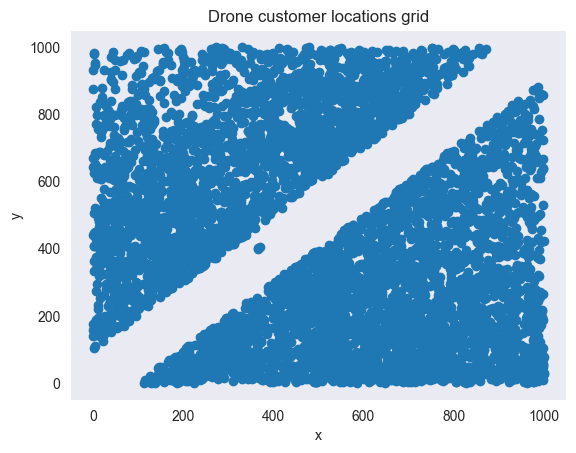

In [3]:
import matplotlib.pyplot as plt
plt.scatter(drone_cust_locations['x'], drone_cust_locations['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Drone customer locations grid')
plt.grid()
plt.show()

The above grid shows a clear divide between customer locations. The central 'void' has next to no customers. This could be an area that is very difficult to provide service at or has other factors that turn away customers.

# Data preparation

In [4]:
# Drop clientid from customer locations and only use the x and y coordinates.
dcl = drone_cust_locations.drop(columns='clientid')
dcl.head()

,x,y
0,622.771572,164.857623
1,416.357298,630.193634
2,292.735020,567.333231
3,737.211288,166.225676
4,540.475375,682.912298


# Modeling

In [5]:
from sklearn.cluster import KMeans

dcl_copy = dcl.copy()
model = KMeans(init='random', n_clusters=3, random_state=42)
model.fit(dcl_copy)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'random'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [6]:
dcl_clusters = dcl.copy()
dcl_clusters['cluster'] = model.labels_
dcl_clusters.head()

,x,y,cluster
0,622.771572,164.857623,0
1,416.357298,630.193634,2
2,292.735020,567.333231,1
3,737.211288,166.225676,0
4,540.475375,682.912298,2


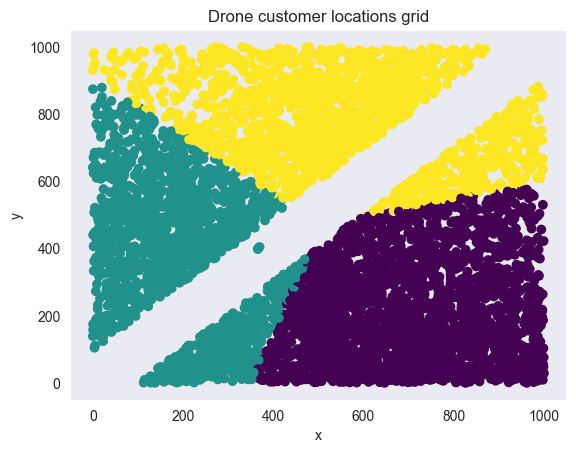

In [7]:
plt.scatter(dcl_clusters['x'], dcl_clusters['y'], c=dcl_clusters['cluster'], cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Drone customer locations grid')
plt.grid()
plt.show()

In [8]:
import time

wcss = []
for i in range(1, 26):
    start_time = time.time()
    model = KMeans(init='random', n_clusters=i, random_state=42).fit(dcl_copy)
    wcss.append(model.inertia_)
    end_time = time.time()
    print(f"[Clusters {i}]: {(end_time - start_time):.4f}s")

[Clusters 1]: 0.0183s
[Clusters 2]: 0.0463s
[Clusters 3]: 0.0637s
[Clusters 4]: 0.0892s
[Clusters 5]: 0.0564s
[Clusters 6]: 0.0668s
[Clusters 7]: 0.0853s
[Clusters 8]: 0.0906s
[Clusters 9]: 0.0961s
[Clusters 10]: 0.0734s
[Clusters 11]: 0.0795s
[Clusters 12]: 0.0828s
[Clusters 13]: 0.0894s
[Clusters 14]: 0.0823s
[Clusters 15]: 0.0879s
[Clusters 16]: 0.1025s
[Clusters 17]: 0.0956s
[Clusters 18]: 0.0802s
[Clusters 19]: 0.1020s
[Clusters 20]: 0.0961s
[Clusters 21]: 0.0801s
[Clusters 22]: 0.0892s
[Clusters 23]: 0.0979s
[Clusters 24]: 0.0864s
[Clusters 25]: 0.0834s


## Elbow method

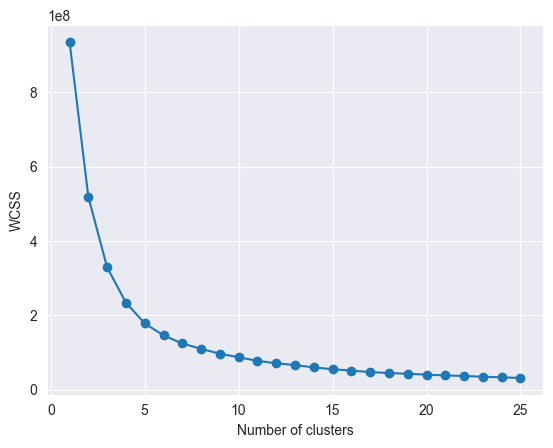

In [9]:
plt.plot(range(1,26), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

The above plot shows the "elbow method" of determining the optimal k value for clusters. The inertia value of each k drops rapidly at start but the decline slows down and becomes gradual as the k value grows. The optimal value is typically found near the elbow, which in this chart seems to correspond with k=5.  
The code cell below creates a new scatter plot with k=5.

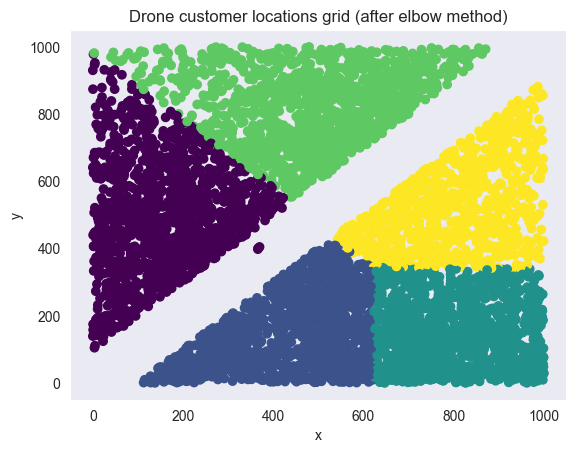

In [10]:
model = KMeans(init='random', n_clusters=5, random_state=42)
model.fit(dcl_copy)
dcl_clusters = dcl.copy()
dcl_clusters['cluster'] = model.labels_
plt.scatter(dcl_clusters['x'], dcl_clusters['y'], c=dcl_clusters['cluster'], cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Drone customer locations grid (after elbow method)')
plt.grid()
plt.show()

## Hierarchical clustering
The k means clustering algorithm is compared to agglomerative hierarchical clustering in order to determine their differences and to potentially find which is more efficient.

In [11]:
from sklearn.cluster import AgglomerativeClustering

for k in range(1, 26):
    start_time = time.time()
    model = AgglomerativeClustering(n_clusters=k)
    model.fit(dcl_copy)
    end_time = time.time()
    print(f"[Clusters {k}]: {(end_time - start_time):.4f}s")

[Clusters 1]: 1.0212s
[Clusters 2]: 0.8980s
[Clusters 3]: 0.8804s
[Clusters 4]: 0.8685s
[Clusters 5]: 0.8794s
[Clusters 6]: 0.9767s
[Clusters 7]: 0.8767s
[Clusters 8]: 0.8857s
[Clusters 9]: 0.9129s
[Clusters 10]: 0.9001s
[Clusters 11]: 0.8711s
[Clusters 12]: 0.8436s
[Clusters 13]: 0.9202s
[Clusters 14]: 0.9033s
[Clusters 15]: 0.8870s
[Clusters 16]: 0.8715s
[Clusters 17]: 0.8274s
[Clusters 18]: 0.8438s
[Clusters 19]: 0.8428s
[Clusters 20]: 0.8613s
[Clusters 21]: 0.9001s
[Clusters 22]: 0.9324s
[Clusters 23]: 0.9276s
[Clusters 24]: 0.8991s
[Clusters 25]: 0.8887s


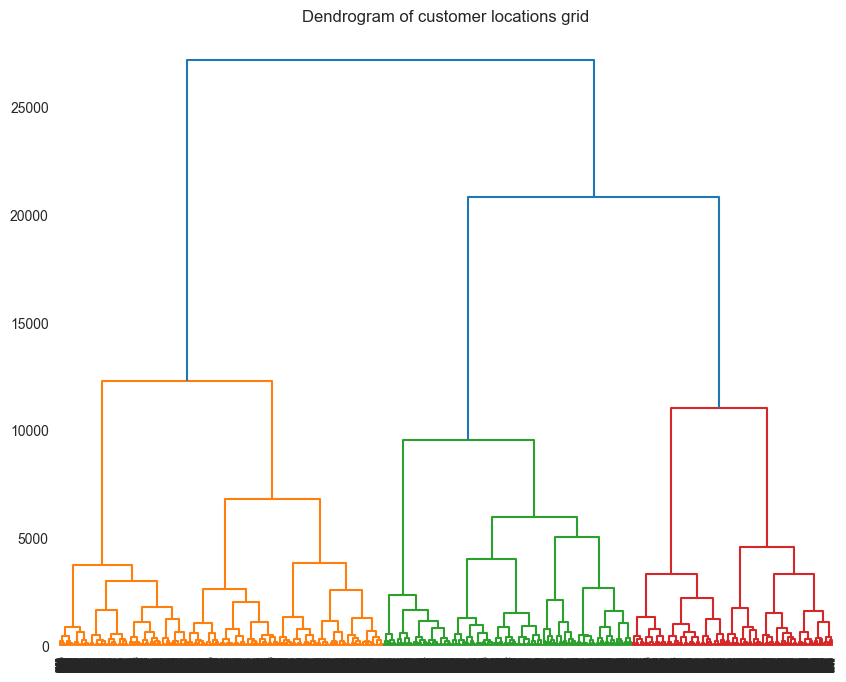

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(dcl_copy, method='ward')
plt.figure(figsize=(10, 8))
dendrogram(Z)
plt.title('Dendrogram of customer locations grid')
plt.show()

# Evaluation

# Deployment